Dataset Length: 5000
Dataset Shape: (5000, 13)

Dataset Head:
  customer_id  age  gender    country  avg_order_value  total_orders  \
0   CUST_8270   30  Female     Brazil           101.08             8   
1   CUST_1860   53  Female        USA            90.39            10   
2   CUST_6390   73    Male  Australia            83.28             6   
3   CUST_6191   30   Other      Japan           109.90             9   
4   CUST_6734   29  Female     Canada           269.38            16   

   last_purchase  is_fraudulent preferred_category  email_open_rate  \
0            176              1             Beauty             25.6   
1             88              0        Electronics             12.3   
2            203              0             Sports              NaN   
3            346              1        Electronics             42.9   
4            342              0            Fashion              5.3   

  customer_since  loyalty_score  churn_risk  
0     2024-06-05             50 

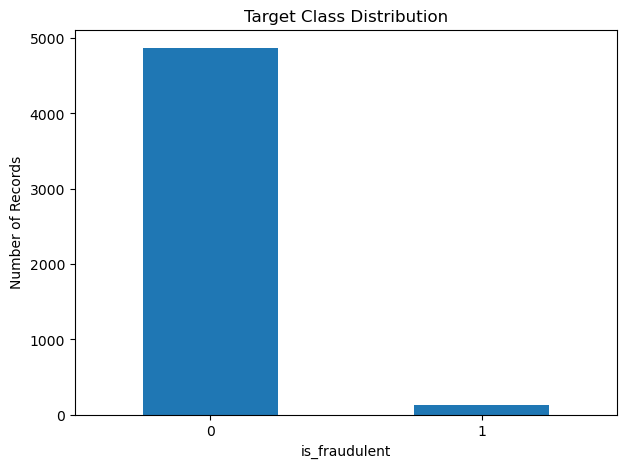

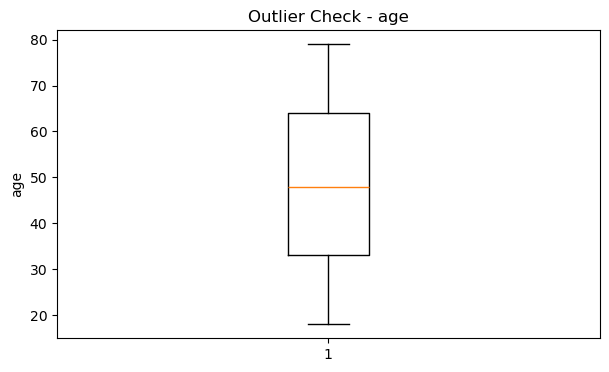

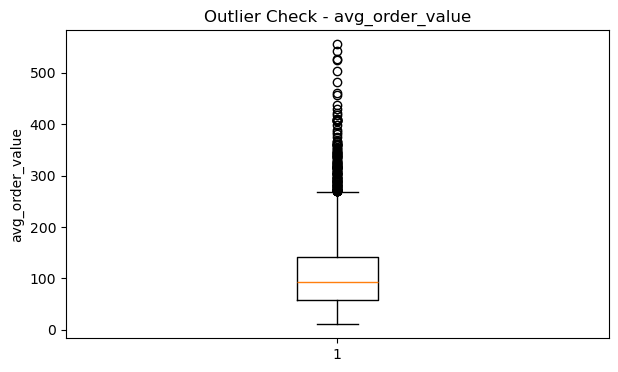

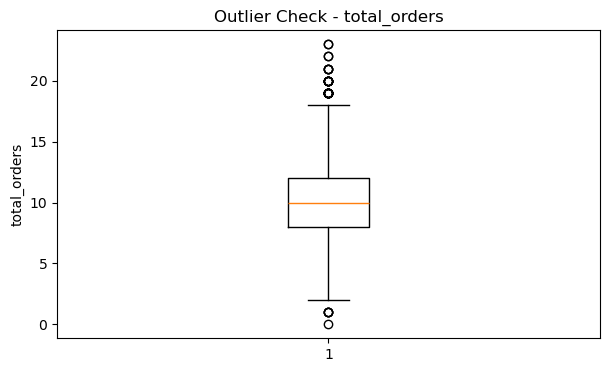

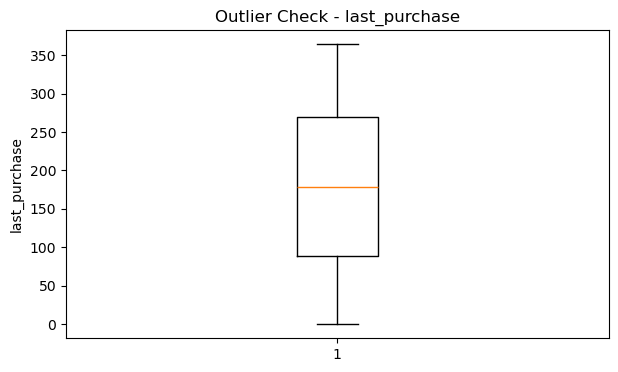

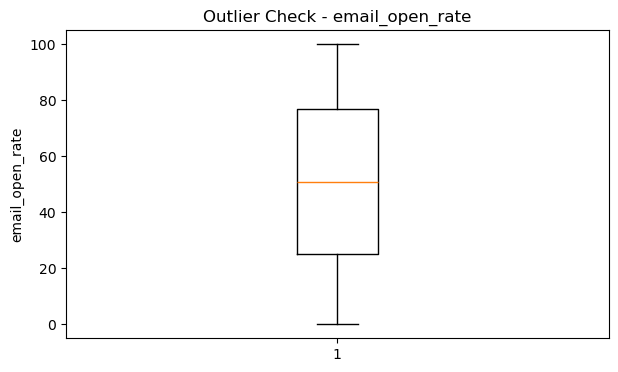

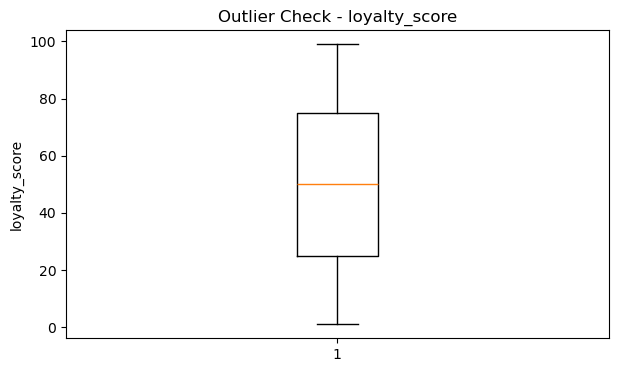

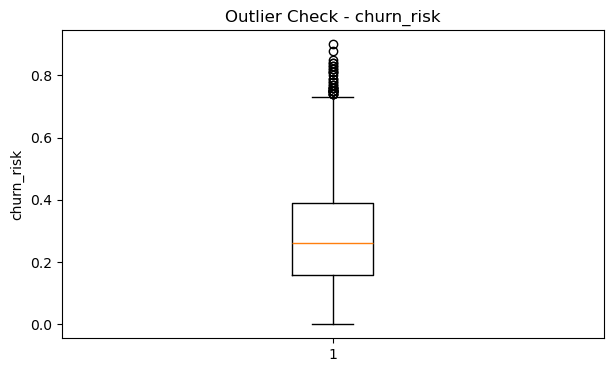


Outlier Count:
age                  0
avg_order_value    137
total_orders        42
last_purchase        0
email_open_rate      0
loyalty_score        0
churn_risk          37
dtype: int64

Shape After Removing Duplicates:
(5000, 13)

Training Data Shape: (3500, 13)
Testing Data Shape: (1500, 13)

Outliers handled using IQR capping.

Encoding Technique: One-Hot Encoding
Scaling Technique: StandardScaler
One-Hot Encoding is suitable because categorical values have no natural order.
StandardScaler was selected to put numeric features on a similar scale.

Class Distribution Before SMOTE:
is_fraudulent
0    3410
1      90
Name: count, dtype: int64

Class Distribution After SMOTE:
is_fraudulent
0    3410
1    3410
Name: count, dtype: int64

SMOTE was applied because the target classes are imbalanced.

========== MODEL TRAINING ==========

XGBoost is not installed.
Install it using: pip install xgboost

Decision Tree

Predicted Values:
[0 0 0 ... 0 0 0]

Confusion Matrix:
[[1390   71]
 [  3

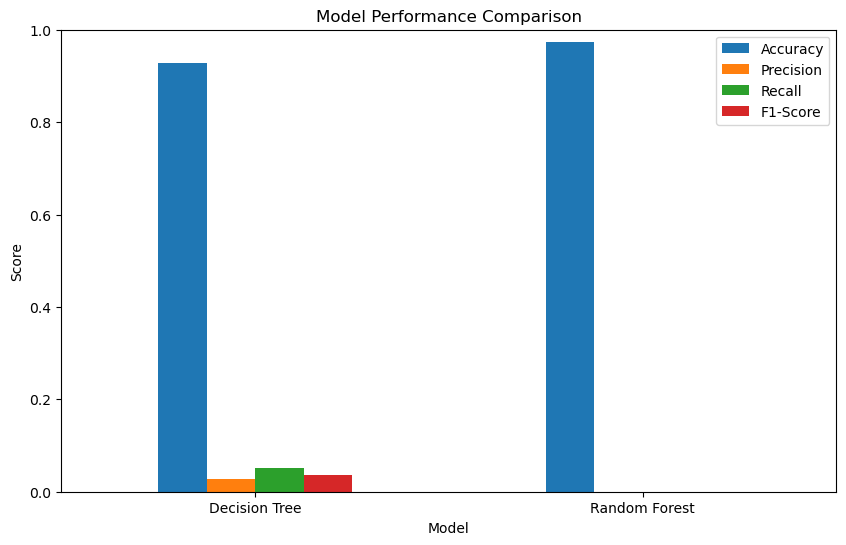

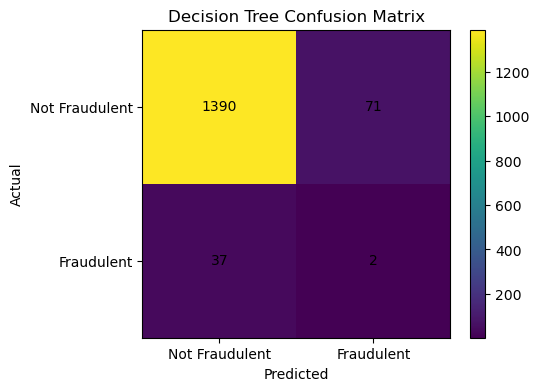

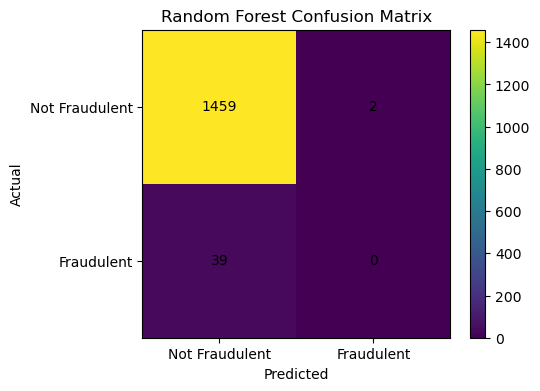

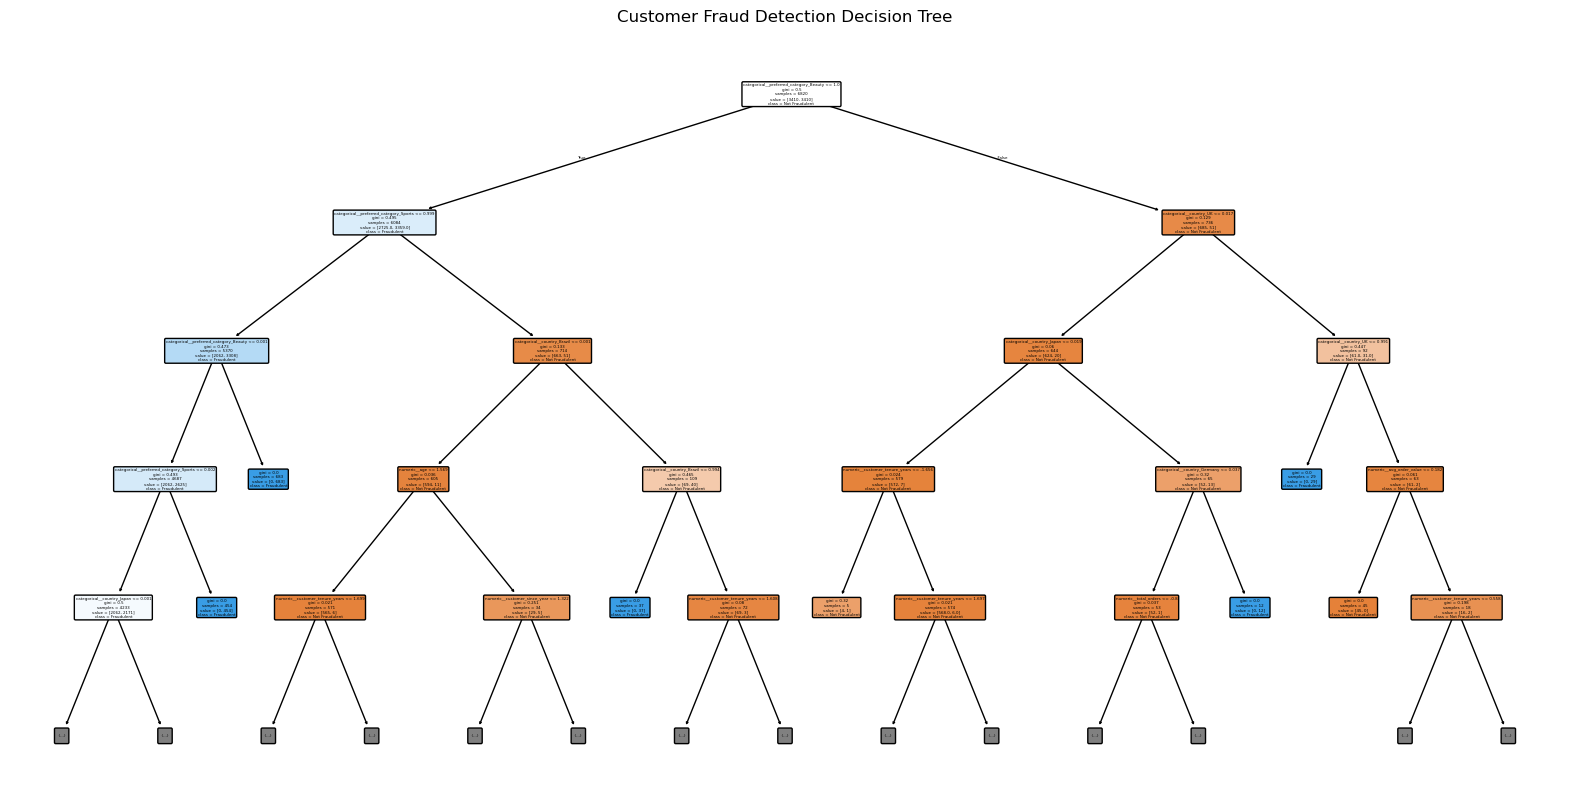


========== BEST MODEL ==========
Best Model: Decision Tree
Accuracy: 0.928
Precision: 0.0273972602739726
Recall: 0.05128205128205128
F1-Score: 0.03571428571428571

========== FINAL PREDICTION RESULTS ==========
    Actual  Predicted
0        0          0
1        0          0
2        0          0
3        0          0
4        0          0
5        0          1
6        0          1
7        0          1
8        0          0
9        0          0
10       0          0
11       0          0
12       0          0
13       0          0
14       0          0
15       0          0
16       0          0
17       0          0
18       0          0
19       0          0

========== ASSIGNMENT SUMMARY ==========
Target Column: is_fraudulent
customer_id was not used as a feature.
Encoding: One-Hot Encoding
Scaling: StandardScaler
Outlier Handling: IQR Capping
Class Balancing: SMOTE
Models: Decision Tree, Random Forest, XGBoost
Best Model Selection: F1-Score


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False


def importdata():
    balance_data = pd.read_csv("customer_analytics_dataset.csv")

    print("Dataset Length:", len(balance_data))
    print("Dataset Shape:", balance_data.shape)
    print("\nDataset Head:")
    print(balance_data.head())

    return balance_data


def eda(balance_data):
    print("\nDataset Information:")
    balance_data.info()

    print("\nMissing Values:")
    print(balance_data.isnull().sum())

    print("\nTotal Missing Values:")
    print(balance_data.isnull().sum().sum())

    print("\nDuplicate Values:")
    print(balance_data.duplicated().sum())

    print("\nTarget Class Distribution:")
    print(balance_data["is_fraudulent"].value_counts())

    print("\nTarget Class Percentage:")
    print(balance_data["is_fraudulent"].value_counts(normalize=True) * 100)

    print("\nStatistical Summary:")
    print(balance_data.describe(include="all"))

    plt.figure(figsize=(7, 5))
    balance_data["is_fraudulent"].value_counts().plot(kind="bar")
    plt.title("Target Class Distribution")
    plt.xlabel("is_fraudulent")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=0)
    plt.show()

def check_outliers(balance_data):
    numeric_columns = balance_data.select_dtypes(include=np.number).columns.tolist()
    numeric_columns.remove("is_fraudulent")

    outlier_count = {}

    for column in numeric_columns:
        q1 = balance_data[column].quantile(0.25)
        q3 = balance_data[column].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_count[column] = (
            (balance_data[column] < lower) |
            (balance_data[column] > upper)
        ).sum()

        plt.figure(figsize=(7, 4))
        plt.boxplot(balance_data[column].dropna())
        plt.title("Outlier Check - " + column)
        plt.ylabel(column)
        plt.show()

    print("\nOutlier Count:")
    print(pd.Series(outlier_count))


def remove_duplicates(balance_data):
    balance_data = balance_data.drop_duplicates().reset_index(drop=True)

    print("\nShape After Removing Duplicates:")
    print(balance_data.shape)

    return balance_data


def create_features(balance_data):
    data = balance_data.copy()

    data["customer_since"] = pd.to_datetime(
        data["customer_since"],
        errors="coerce"
    )

    reference_date = data["customer_since"].max()

    data["customer_tenure_years"] = (
        (reference_date - data["customer_since"]).dt.days / 365.25
    )

    data["customer_since_year"] = data["customer_since"].dt.year
    data["customer_since_month"] = data["customer_since"].dt.month

    data = data.drop(
        ["customer_id", "customer_since"],
        axis=1
    )

    return data


def splitdataset(balance_data):
    data = create_features(balance_data)

    X = data.drop("is_fraudulent", axis=1)
    Y = data["is_fraudulent"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        Y,
        test_size=0.30,
        random_state=100,
        stratify=Y
    )

    print("\nTraining Data Shape:", X_train.shape)
    print("Testing Data Shape:", X_test.shape)

    return X_train, X_test, y_train, y_test


def handle_outliers(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    numeric_columns = X_train.select_dtypes(include=np.number).columns

    for column in numeric_columns:
        q1 = X_train[column].quantile(0.25)
        q3 = X_train[column].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        X_train[column] = X_train[column].clip(lower, upper)
        X_test[column] = X_test[column].clip(lower, upper)

    return X_train, X_test

def preprocess_data(X_train, X_test):
    numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
    categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns)
    ])

    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    feature_names = preprocessor.get_feature_names_out()

    X_train_processed = pd.DataFrame(
        X_train_processed,
        columns=feature_names,
        index=X_train.index
    )

    X_test_processed = pd.DataFrame(
        X_test_processed,
        columns=feature_names,
        index=X_test.index
    )

    print("\nEncoding Technique: One-Hot Encoding")
    print("Scaling Technique: StandardScaler")

    return X_train_processed, X_test_processed

def apply_smote(X_train, y_train):
    print("\nClass Distribution Before SMOTE:")
    print(y_train.value_counts())

    smote = SMOTE(random_state=100)

    X_train_smote, y_train_smote = smote.fit_resample(
        X_train,
        y_train
    )

    print("\nClass Distribution After SMOTE:")
    print(pd.Series(y_train_smote).value_counts())

    print("\nSMOTE was applied because the target classes are imbalanced.")

    return X_train_smote, y_train_smote


def train_decision_tree(X_train, y_train):
    clf_decision_tree = DecisionTreeClassifier(
        criterion="gini",
        random_state=100,
        max_depth=10,
        min_samples_leaf=5
    )
    clf_decision_tree.fit(X_train, y_train)

    return clf_decision_tree

def train_random_forest(X_train, y_train):
    clf_random_forest = RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=3,
        random_state=100,
        n_jobs=-1
    )

    clf_random_forest.fit(X_train, y_train)

    return clf_random_forest


def train_xgboost(X_train, y_train):
    if xgb_available == False:
        return None

    clf_xgboost = XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=100
    )

    clf_xgboost.fit(X_train, y_train)

    return clf_xgboost


def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)

    print("\nPredicted Values:")
    print(y_pred)

    return y_pred


def cal_accuracy(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nAccuracy:")
    print(accuracy)

    print("\nPrecision:")
    print(precision)

    print("\nRecall:")
    print(recall)

    print("\nF1-Score:")
    print(f1)

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Not Fraudulent", "Fraudulent"],
        zero_division=0
    ))

    return accuracy, precision, recall, f1


def evaluate_models(models, X_test, y_test):
    results = []

    for model_name, model in models.items():
        if model is None:
            continue

        print(model_name)
        print("=============")

        y_pred = prediction(X_test, model)

        accuracy, precision, recall, f1 = cal_accuracy(
            y_test,
            y_pred
        )

        results.append({
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        })

    results_df = pd.DataFrame(results)

    print("\n========== MODEL COMPARISON ==========")
    print(results_df)

    return results_df


def plot_model_comparison(results_df):
    results_plot = results_df.set_index("Model")[
        ["Accuracy", "Precision", "Recall", "F1-Score"]
    ]

    results_plot.plot(
        kind="bar",
        figsize=(10, 6)
    )

    plt.title("Model Performance Comparison")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(rotation=0)
    plt.show()


def plot_confusion_matrices(models, X_test, y_test):
    for model_name, model in models.items():
        if model is None:
            continue

        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        plt.figure(figsize=(5, 4))
        plt.imshow(cm)
        plt.title(model_name + " Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.colorbar()

        for i in range(len(cm)):
            for j in range(len(cm[i])):
                plt.text(j, i, cm[i][j], ha="center", va="center")

        plt.xticks([0, 1], ["Not Fraudulent", "Fraudulent"])
        plt.yticks([0, 1], ["Not Fraudulent", "Fraudulent"])
        plt.show()


def plot_decision_tree(clf_object, feature_names):
    plt.figure(figsize=(20, 10))

    plot_tree(
        clf_object,
        feature_names=feature_names,
        class_names=["Not Fraudulent", "Fraudulent"],
        filled=True,
        max_depth=4,
        rounded=True
    )

    plt.title("Customer Fraud Detection Decision Tree")
    plt.show()


def final_prediction(best_model, X_test, y_test):
    y_pred = best_model.predict(X_test)

    final_result = pd.DataFrame({
        "Actual": y_test.values,
        "Predicted": y_pred
    })

    print("\n==========  PREDICTION")
    print(final_result.head(20))

    return final_result


if __name__ == "__main__":

    data = importdata()

    eda(data)

    check_outliers(data)

    data = remove_duplicates(data)

    X_train, X_test, y_train, y_test = splitdataset(data)

    X_train, X_test = handle_outliers(
        X_train,
        X_test
    )

    X_train, X_test = preprocess_data(
        X_train,
        X_test
    )

    X_train_smote, y_train_smote = apply_smote(
        X_train,
        y_train
    )

    print("\n========== MODEL TRAINING ==========")

    clf_decision_tree = train_decision_tree(
        X_train_smote,
        y_train_smote
    )

    clf_random_forest = train_random_forest(
        X_train_smote,
        y_train_smote
    )

    clf_xgboost = train_xgboost(
        X_train_smote,
        y_train_smote
    )

    models = {
        "Decision Tree": clf_decision_tree,
        "Random Forest": clf_random_forest,
        "XGBoost": clf_xgboost
    }

    results = evaluate_models(
        models,
        X_test,
        y_test
    )

    plot_model_comparison(results)

    plot_confusion_matrices(
        models,
        X_test,
        y_test
    )

    plot_decision_tree(
        clf_decision_tree,
        X_train.columns
    )

    best_model_name = results.loc[
        results["F1-Score"].idxmax(),
        "Model"
    ]

    best_model = models[best_model_name]

    best_row = results[
        results["Model"] == best_model_name
    ].iloc[0]

    print("\n========== BEST MODEL ")
    print("Best Model:", best_model_name)
    print("Accuracy:", best_row["Accuracy"])
    print("Precision:", best_row["Precision"])
    print("Recall:", best_row["Recall"])
    print("F1-Score:", best_row["F1-Score"])

    final_prediction(
        best_model,
        X_test,
        y_test
    )

    print("\n========== ASSIGNMENT SUMMARY ")
    print("Target Column: is_fraudulent")
    print("customer_id was not used as a feature.")
    print("Encoding: One-Hot Encoding")
    print("Scaling: StandardScaler")
    print("Outlier Handling: IQR Capping")
    print("Class Balancing: SMOTE")
    print("Models: Decision Tree, Random Forest, XGBoost")
    print("Best Model Selection: F1-Score")
